In [1]:
import sys
import os
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from utils.glm_wrapper_functions_cluster import glm_wrapper_functions_cluster

In [2]:
import numpy as np
from scipy.ndimage import gaussian_filter1d

def smooth_spike_trials(Y_trials, sigma=2.0):
    """
    Smooth binarized spike/deconvolved trials along time only.

    Parameters
    ----------
    Y_trials : list of np.ndarray
        Each array has shape [T, n_neurons].
    sigma : float
        Gaussian sigma in units of frames.

    Returns
    -------
    Y_smooth_trials : list of np.ndarray
        Smoothed arrays, same shape as input.
    """
    Y_smooth_trials = []
    for Y in Y_trials:
        Y_smooth = gaussian_filter1d(
            Y.astype(np.float32),
            sigma=sigma,
            axis=0,          # smooth over time
            mode="nearest"
        )
        Y_smooth_trials.append(Y_smooth)
    return Y_smooth_trials

In [3]:
# Load the data
glm_wrapper = glm_wrapper_functions_cluster()
mouse,date,model_name,server = 'HA11-1R','2023-05-05','GLM_3nmf_pre', 'V:'
data_directory = os.path.join('V:/Connie/ProcessedData',mouse,date,model_name) 
# data_directory = os.path.join('/ix/crunyan/cdb66/Data',mouse,date,model_name) #SLURM ALREADY CD's to the directory
# save_directory = os.path.join('/ix/crunyan/cdb66/Data',mouse,date,model_name,'results_updated')

num_folds = 1
model_data_all = {}
for fold_number in list(range(0,num_folds)): #can change this to fit however many folds you need 

    train_directory = data_directory + "/prepost trial cv 73 #{}".format(fold_number+1)
    test_directory = data_directory + "/prepost trial cv 73 #{}/test".format(fold_number+1)
    
    X_train_trials,Y_train_trials,X_test_trials,Y_test_trials,correct_train,correct_test,_,IDS_for_count_of_values = glm_wrapper.get_glm_predictors_data_from_each_CV_fold(
        train_directory,
        test_directory,
        fold_number,
        raw_deconvolved=0,
        ctx_value=1)

    model_name = 'GLM_3nmf_passive'
    X_train_trials_pass,Y_train_trials_pass,X_test_trials_pass,Y_test_trials_pass,_,_,_,IDS_for_count_of_values = glm_wrapper.get_glm_predictors_data_from_each_CV_fold(
        train_directory,
        test_directory,
        fold_number,
        raw_deconvolved=0,
        ctx_value=0)
    
    # smooth neural responses
    Y_test_trials = smooth_spike_trials(Y_test_trials, sigma=2)
    Y_train_trials = smooth_spike_trials(Y_train_trials, sigma=2)
    
print(f'Make sure sizes of correct_trials train: {len(correct_train)} and Xtrain {len(X_train_trials)} match')


None
Make sure sizes of correct_trials train: 158 and Xtrain 158 match


In [4]:
# # Import common packages
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

class SimpleRateRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, alpha=0.2):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.alpha = alpha

        # Input and recurrent weights
        self.W_in = nn.Linear(input_dim, hidden_dim, bias=True)
        self.W_rec = nn.Linear(hidden_dim, hidden_dim, bias=False)

        # Output readout (choice)
        self.W_out = nn.Linear(hidden_dim, output_dim)

    def forward_trial(self, X):
        """
        X: Tensor [T, D] for one trial
        Returns:
            logits: Tensor [output_dim]
            hidden_states: Tensor [T, hidden_dim]
        """
        T = X.shape[0]
        h = torch.zeros(self.hidden_dim, device=X.device)

        hidden_states = []

        for t in range(T):
            h = (1 - self.alpha) * h + self.alpha * torch.tanh(
                self.W_rec(h) + self.W_in(X[t])
            )
            hidden_states.append(h)

        hidden_states = torch.stack(hidden_states, dim=0)

        # Readout from final state
        logits = self.W_out(h)

        return logits, hidden_states

    


In [5]:
# Prepare data for PyTorch and convert to tensors
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_trials_torch = [
    torch.tensor(X, dtype=torch.float32, device=device)
    for X in X_train_trials
]

y_train_labels = correct_train  # assuming correct_train is a list of labels per trial
y_train = torch.tensor(
    y_train_labels, dtype=torch.long, device=device
)


C:\Users\runyan1\AppData\Local\Temp\ipykernel_37624\2391609422.py:10: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
  y_train = torch.tensor(


In [6]:
# instantiate the model
input_dim = X_train_trials_torch[0].shape[1]
hidden_dim = 128     # start modest
output_dim = 2       # left / right

all_hidden_states = []
all_logits = []
all_labels = []

model = SimpleRateRNN(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    output_dim=output_dim,
    alpha=0.2
).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Training loop
n_epochs = 5 #was 20
for epoch in range(n_epochs):
    model.train()
    total_loss = 0.0

    for k, X_trial in enumerate(X_train_trials_torch):
        optimizer.zero_grad()

        logits, hidden_states = model.forward_trial(X_trial)

        all_hidden_states.append(hidden_states.detach().cpu())
        all_logits.append(logits.detach().cpu())
        all_labels.append(y_train[k].item())

        loss = criterion(
            logits.unsqueeze(0),  # [1, 2]
            y_train[k].unsqueeze(0)
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch:02d} | Loss = {total_loss:.3f}")

Epoch 00 | Loss = 21.093
Epoch 01 | Loss = 17.287
Epoch 02 | Loss = 16.118
Epoch 03 | Loss = 15.655
Epoch 04 | Loss = 15.445


In [7]:
#sanity tests
logits_np = torch.stack(all_logits).numpy()
preds = np.argmax(logits_np, axis=1)
labels = np.array(all_labels)

accuracy = np.mean(preds == labels) # did model learn anything beyond chance?
print("Training accuracy:", accuracy)

Training accuracy: 0.9556962025316456


In [8]:
model.eval()
test_preds = []
test_labels = []

X_test_trials_torch = [
    torch.tensor(X, dtype=torch.float32, device=device)
    for X in X_test_trials
]

y_test_labels = correct_test  # assuming correct_train is a list of labels per trial
y_test = torch.tensor(
    y_test_labels, dtype=torch.long, device=device
)

with torch.no_grad():
    for k, X_trial in enumerate(X_test_trials_torch):
        logits, _ = model.forward_trial(X_trial)
        pred = torch.argmax(logits).item()
        test_preds.append(pred)
        test_labels.append(y_test[k])

test_acc = np.mean(np.array(test_preds) == np.array(test_labels))
print("Test accuracy:", test_acc)


C:\Users\runyan1\AppData\Local\Temp\ipykernel_37624\1840081431.py:11: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
  y_test = torch.tensor(


Test accuracy: 0.7903225806451613


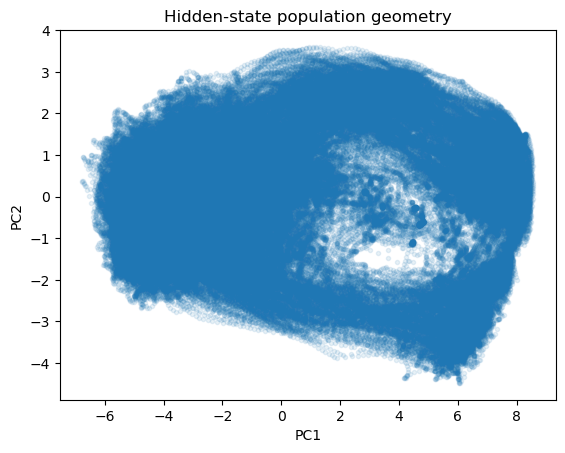

In [9]:
# Quick look at hidden states with PCA
H = np.concatenate(all_hidden_states, axis=0)  # [sum T, N]
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=3)
H_pca = pca.fit_transform(H)

plt.figure()
plt.plot(H_pca[:,0], H_pca[:,1], '.', alpha=0.1)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Hidden-state population geometry')
plt.show() #Tight cloud → weak dynamics

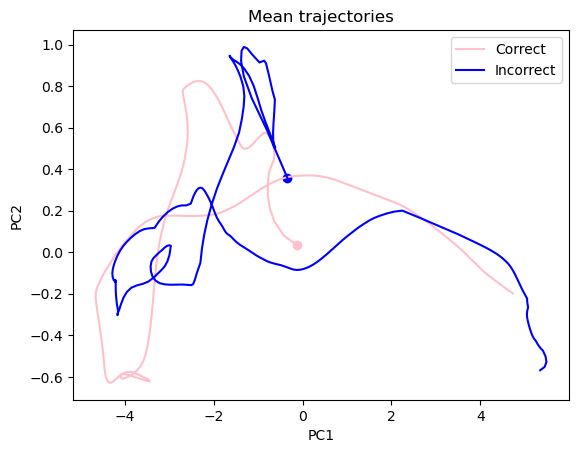

In [10]:
def mean_trajectory(trials):
    min_len = min(h.shape[0] for h in trials)
    return np.mean([h[:min_len] for h in trials], axis=0)

correct_trials = [h for h, y in zip(all_hidden_states, labels) if y == 1]
incorrect_trials = [h for h, y in zip(all_hidden_states, labels) if y == 0]

mean_correct = mean_trajectory(correct_trials)
mean_incorrect = mean_trajectory(incorrect_trials)

mean_correct_pca = pca.transform(mean_correct)
mean_incorrect_pca = pca.transform(mean_incorrect)

plt.figure()
plt.plot(mean_correct_pca[:,0], mean_correct_pca[:,1], label='Correct', color = 'pink')
plt.plot(mean_incorrect_pca[:,0], mean_incorrect_pca[:,1], label='Incorrect',color = 'blue')
#scatter for first point
plt.scatter(mean_correct_pca[0,0], mean_correct_pca[0,1], color = 'pink')
plt.scatter(mean_incorrect_pca[0,0], mean_incorrect_pca[0,1],color = 'blue')
plt.legend()
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Mean trajectories')
plt.show()


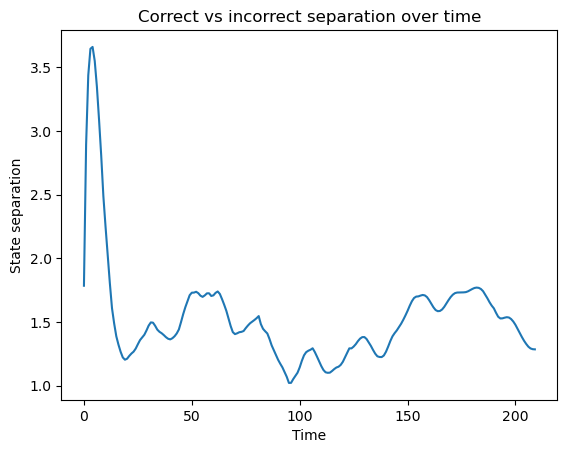

In [11]:
def separation_over_time(trials, labels):
    min_len = min(h.shape[0] for h in trials)
    dists = []

    for t in range(min_len):
        mean_c = np.mean([h[t] for h, y in zip(trials, labels) if y == 1], axis=0)
        mean_i = np.mean([h[t] for h, y in zip(trials, labels) if y == 0], axis=0)
        dists.append(np.linalg.norm(mean_c - mean_i))

    return np.array(dists)

sep = separation_over_time(all_hidden_states, labels)

plt.figure()
plt.plot(sep)
plt.xlabel('Time')
plt.ylabel('State separation')
plt.title('Correct vs incorrect separation over time')
plt.show()


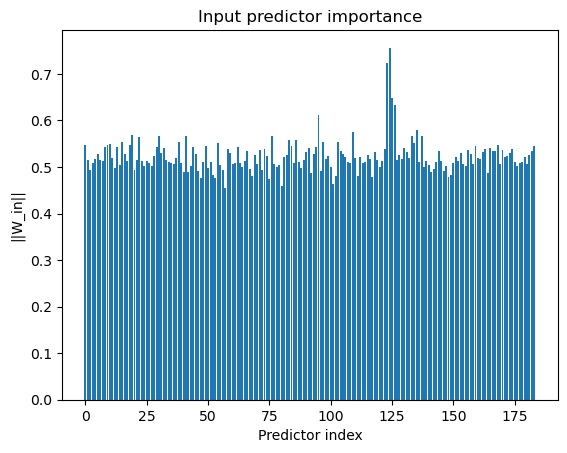

In [12]:
W_in = model.W_in.weight.detach().cpu().numpy()
input_strength = np.linalg.norm(W_in, axis=0)

plt.figure()
plt.bar(np.arange(len(input_strength)), input_strength)
plt.xlabel('Predictor index')
plt.ylabel('||W_in||')
plt.title('Input predictor importance')
plt.show()


Passive-context test accuracy: 0.7903225806451613


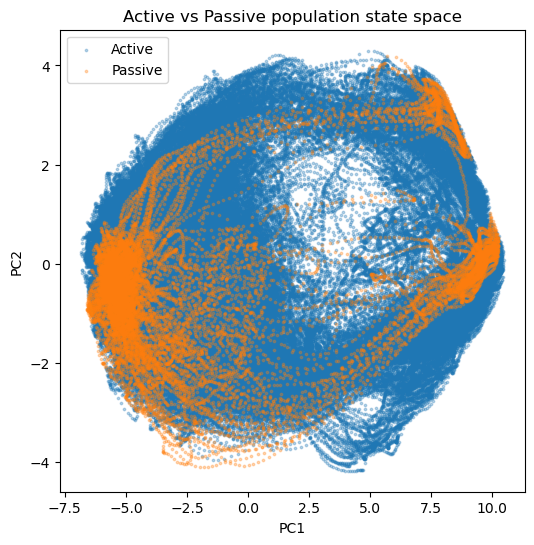

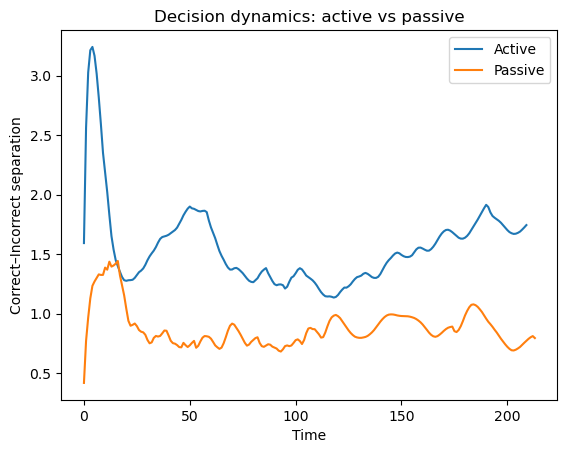

In [44]:
X_test_passive_torch = [
    torch.tensor(X, dtype=torch.float32, device=device)
    for X in X_test_trials_pass
]


# run the passive test loop (no gradients)
model.eval()

passive_logits = []
passive_hidden_states = []

with torch.no_grad():
    for X_trial in X_test_passive_torch:
        logits, hidden_states = model.forward_trial(X_trial)
        passive_logits.append(logits.cpu())
        passive_hidden_states.append(hidden_states.cpu())

#sanity tests
passive_preds = [torch.argmax(l).item() for l in passive_logits]
passive_acc = np.mean(np.array(passive_preds) == np.array(test_labels))

print("Passive-context test accuracy:", passive_acc)

H_active = np.concatenate([h.numpy() for h in all_hidden_states], axis=0)
H_passive = np.concatenate([h.numpy() for h in passive_hidden_states], axis=0)

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=3)
H_active_pca = pca.fit_transform(H_active)
H_passive_pca = pca.transform(H_passive)

plt.figure(figsize=(6,6))
plt.scatter(H_active_pca[:,0], H_active_pca[:,1],
            s=3, alpha=0.3, label='Active')
plt.scatter(H_passive_pca[:,0], H_passive_pca[:,1],
            s=3, alpha=0.3, label='Passive')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.title('Active vs Passive population state space')
plt.show()

#Time-resolved separation (active vs passive)
sep_active = separation_over_time(all_hidden_states, labels)
sep_passive = separation_over_time(passive_hidden_states, labels)

plt.figure()
plt.plot(sep_active, label='Active')
plt.plot(sep_passive, label='Passive')
plt.xlabel('Time')
plt.ylabel('Correct–Incorrect separation')
plt.legend()
plt.title('Decision dynamics: active vs passive')
plt.show()






In [45]:
np.var(H_passive_pca[:,0]) / np.var(H_active_pca[:,0])


1.2310652

In [46]:
with torch.no_grad():
    _, h1 = model.forward_trial(X_train_trials_torch[0])
    _, h2 = model.forward_trial(X_train_trials_torch[0])
    assert torch.allclose(h1[0], h2[0])


Update RNN with specified weights following Dale's Law and 

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DaleRateRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim,
                 n_neurons,  # number of recorded neurons to predict
                 dale_sign,  # Tensor [hidden_dim], +1 for Pyr, -1 for PV/SOM
                 alpha=0.2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.alpha = alpha

        # Input weights (unconstrained)
        self.W_in = nn.Linear(input_dim, hidden_dim, bias=True)

        # Recurrent weights: learn unconstrained Theta, transform to Dale matrix
        self.Theta_rec = nn.Parameter(torch.randn(hidden_dim, hidden_dim) * 0.05)
        self.register_buffer("dale_sign", dale_sign.view(hidden_dim, 1))  # [N,1]

        # Choice readout (from final state)
        self.W_out = nn.Linear(hidden_dim, output_dim)

        # Neural activity readout (from each timepoint)
        self.C = nn.Linear(hidden_dim, n_neurons, bias=True)

    def W_rec(self):
        W_pos = F.softplus(self.Theta_rec)           # >= 0
        return self.dale_sign * W_pos                # rows sign-constrained

    def forward_trial(self, X):
        T = X.shape[0]
        h = torch.zeros(self.hidden_dim, device=X.device)

        hs = []
        yhats = []

        Wrec = self.W_rec()

        for t in range(T):
            pre = (Wrec @ h) + self.W_in(X[t])
            h = (1 - self.alpha) * h + self.alpha * torch.tanh(pre)

            hs.append(h)

            # IMPORTANT: raw logits (no sigmoid here)
            yhat_t = F.softplus(self.C(h)) #self.C(h) < this one is unconstrained, but we want to enforce non-negativity for firing rates
            
            yhats.append(yhat_t)

        hs = torch.stack(hs, dim=0)         # [T, hidden_dim]
        yhat_logits = torch.stack(yhats, dim=0)  # [T, n_neurons]

        logits = self.W_out(h)

        return logits, hs, yhat_logits



hidden_dim = 128
n_pyr = int(0.7 * hidden_dim)
n_pv  = int(0.2 * hidden_dim)
n_som = hidden_dim - n_pyr - n_pv

dale_sign = torch.cat([
    torch.ones(n_pyr),
    -torch.ones(n_pv),
    -torch.ones(n_som)
]).to(device)


In [14]:


y_neural_train =  [
    torch.tensor(Y, dtype=torch.float32, device=device)
    for Y in Y_train_trials ] 


model = DaleRateRNN(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    output_dim=2,                # correct / incorrect
    n_neurons=y_neural_train[0].shape[1],
    dale_sign=dale_sign,
    alpha=0.2
).to(device)


#Loss functions + optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

criterion_choice = nn.CrossEntropyLoss()
# criterion_neural = nn.MSELoss()
# criterion_neural = nn.BCELoss()
# pos_rate = np.array(Y_train_trials).mean().item()  # ~0.025 from earlier #what we are doing here is scaling things? based on the mean spikes per frame (~2.5% of neurons have spikes per frame)
# pos_weight = torch.tensor((1 - pos_rate) / pos_rate, device=device)
# pos_weight = torch.tensor(39.0, device=device)
criterion_neural = nn.MSELoss()#nn.BCEWithLogitsLoss() #(pos_weight=pos_weight)


lambda_neural = 5.0   # 1.0 start here, tune later (was doing 50 before)




In [34]:
#Training loop
n_epochs = 50

for epoch in range(n_epochs):

    model.train()
    total_loss = 0
    total_choice_loss = 0
    total_neural_loss = 0

    for k in range(len(X_train_trials_torch)):

        X_trial = X_train_trials_torch[k]
        Y_trial = y_neural_train[k]

        optimizer.zero_grad()

        logits, hidden_states, yhat = model.forward_trial(X_trial)

        # ----- Choice loss (trial-level) -----
        loss_choice = criterion_choice(
            logits.unsqueeze(0),
            y_train[k].unsqueeze(0)
        )

        # ----- Weighted neural prediction loss -----

        beta = 20 #test different values of beta to see how it affects the weighting of neural events, (5,20,25,50)

        # Larger neural events receive more weight
        weights = 1.0 + beta * Y_trial

        # Squared error at every timepoint x neuron
        squared_error = (yhat - Y_trial) ** 2

        # Weighted MSE
        loss_neural = (weights * squared_error).sum() / weights.sum()

        # ----- Combined loss -----
        loss = loss_choice + lambda_neural * loss_neural

        # # ----- Neural prediction loss (time-resolved) -----
        # loss_neural = criterion_neural(yhat, Y_trial)

        # # ----- Combined loss -----
        # loss = lambda_neural * loss_neural#loss_choice + lambda_neural * loss_neural

        loss.backward()

        # optional: gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()
        total_choice_loss += loss_choice.item()
        total_neural_loss += loss_neural.item()

    print(
        f"Epoch {epoch:02d} | "
        f"Total {total_loss:.3f} | "
        f"Choice {total_choice_loss:.3f} | "
        f"Neural {total_neural_loss:.3f}"
    )


Epoch 00 | Total 35.622 | Choice 24.167 | Neural 2.291
Epoch 01 | Total 34.815 | Choice 23.373 | Neural 2.288
Epoch 02 | Total 34.526 | Choice 23.095 | Neural 2.286
Epoch 03 | Total 33.745 | Choice 22.329 | Neural 2.283
Epoch 04 | Total 33.347 | Choice 21.944 | Neural 2.281
Epoch 05 | Total 33.307 | Choice 21.923 | Neural 2.277
Epoch 06 | Total 32.819 | Choice 21.457 | Neural 2.272
Epoch 07 | Total 32.572 | Choice 21.226 | Neural 2.269
Epoch 08 | Total 33.399 | Choice 22.072 | Neural 2.265
Epoch 09 | Total 32.124 | Choice 20.811 | Neural 2.263
Epoch 10 | Total 32.045 | Choice 20.755 | Neural 2.258
Epoch 11 | Total 30.736 | Choice 19.465 | Neural 2.254
Epoch 12 | Total 31.304 | Choice 20.056 | Neural 2.250
Epoch 13 | Total 30.492 | Choice 19.258 | Neural 2.247
Epoch 14 | Total 30.080 | Choice 18.866 | Neural 2.243
Epoch 15 | Total 29.835 | Choice 18.637 | Neural 2.239
Epoch 16 | Total 29.515 | Choice 18.334 | Neural 2.236
Epoch 17 | Total 29.080 | Choice 17.916 | Neural 2.233
Epoch 18 |

In [23]:
import scipy
def load_celltypes(server,animalID,date):
    base_path = f"{server}/Connie/ProcessedData/{animalID}/{date}/"


    path = os.path.join(base_path, 'red_variables/')
    pyr_str = scipy.io.loadmat(path+'pyr_cells.mat')
    pyr = pyr_str['pyr_cells']-1 #convert to python indices
    pyr = np.transpose(pyr)

    som_str = scipy.io.loadmat(path+'mcherry_cells.mat')
    som = som_str['mcherry_cells']-1

    pv_str = scipy.io.loadmat(path+'tdtom_cells.mat')
    pv = pv_str['tdtom_cells']-1


    neuron_groups = {
        'pyr': pyr,
        'som': som,
        'pv': pv}

    # Define colors for each group
    colors = {'pyr': (0.37, 0.75, 0.49),   # pyr = 0
            'som': (0.17, 0.35, 0.8),    # som = 1
            'pv': (0.82, 0.04, 0.04)}    # pv = 2

    #combine celltypes into different indices
    celltype_array = np.zeros(np.shape(np.concatenate((pyr,som,pv)))[0])
    celltype_array[som] = 1
    celltype_array[pv] = 2

    return celltype_array, neuron_groups, colors

celltype_array, neuron_groups, colors = load_celltypes('V:',mouse,date)

In [35]:
#sanity checks
#(1) variance explained by the model
with torch.no_grad():
    logits, hs, yhat = model.forward_trial(X_trial)

r2 = 1 - torch.var(Y_trial - yhat) / torch.var(Y_trial)
print("Example R²:", r2.item())

print("Mean predicted:", yhat.mean().item())
print("Mean actual:", Y_trial.mean().item())

#(2) check that signs make sense
Wrec = model.W_rec().detach()

print("Min Pyr row:", Wrec[:n_pyr].min()) #SHOULD BE POSITIVE NUMBER
print("Max PV row:", Wrec[n_pyr:n_pyr+n_pv].max()) #SHOULD BE NEGATIVE NUMBER



#(3) split neural loss by cell type
pyr_idx = neuron_groups['pyr']
pv_idx = neuron_groups['pv']
som_idx = neuron_groups['som']

loss_neural = (
    criterion_neural(yhat[:, pyr_idx], Y_trial[:, pyr_idx]) +
    criterion_neural(yhat[:, pv_idx],  Y_trial[:, pv_idx]) +
    criterion_neural(yhat[:, som_idx], Y_trial[:, som_idx])
)

print(loss_neural)


Example R²: -0.06644785404205322
Mean predicted: 0.054033312946558
Mean actual: 0.025269974023103714
Min Pyr row: tensor(0.1095)
Max PV row: tensor(-0.2477)
tensor(0.0190)


Mean predicted: 0.054033312946558
Mean actual: 0.025269974023103714


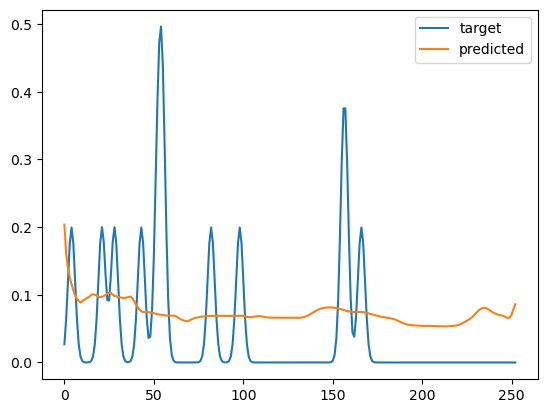

In [42]:
## code below is for binary prediction sanity checks, but since we're doing MSE on smoothed firing rates, it's less relevant. Keeping here for reference if we want to switch loss functions later.
# yhat_prob = torch.sigmoid(yhat)
# print("Mean predicted:", yhat_prob.mean().item())
# print("Mean actual:", Y_trial.mean().item())

# i = 5
# plt.plot(Y_trial[:, i])
# plt.plot(torch.sigmoid(yhat)[:, i])


print("Mean predicted:", yhat.mean().item())
print("Mean actual:", Y_trial.mean().item())

i = 3 #5,3,2
plt.plot(Y_trial[:, i].detach().cpu().numpy(), label="target")
plt.plot(yhat[:, i].detach().cpu().numpy(), label="predicted")
plt.legend()
plt.show()


In [43]:
from scipy.stats import pearsonr
import numpy as np

Y_np = Y_trial.detach().cpu().numpy()
Yhat_np = yhat.detach().cpu().numpy()

r_all = []

for n in range(Y_np.shape[1]):

    target = Y_np[:, n]
    pred = Yhat_np[:, n]

    if np.std(target) > 0 and np.std(pred) > 0:
        r, _ = pearsonr(target, pred)
        r_all.append(r)

r_all = np.array(r_all)

print("Mean r:", np.mean(r_all))
print("Median r:", np.median(r_all))
print("% neurons r > 0:", np.mean(r_all > 0) * 100)
print("% neurons r > 0.2:", np.mean(r_all > .2) * 100)
print("% neurons r > 0.3:", np.mean(r_all > .3) * 100)



Mean r: 0.13146811078017367
Median r: 0.08624254307624576
% neurons r > 0: 65.21739130434783
% neurons r > 0.2: 35.07246376811594
% neurons r > 0.3: 24.637681159420293


In [44]:
# run code on test trials (active context)
# Convert test inputs to PyTorch tensors
X_test_trials_torch = [
    torch.tensor(X, dtype=torch.float32, device=device)
    for X in X_test_trials
]

# Put trained model into evaluation mode
model.eval()

yhat_test = []
hidden_states_test = []
logits_test = []

# Predict neural activity on held-out test trials
with torch.no_grad():

    for X_trial in X_test_trials_torch:

        logits, hidden_states, yhat = model.forward_trial(X_trial)

        yhat_test.append(yhat.cpu().numpy())
        hidden_states_test.append(hidden_states.cpu().numpy())
        logits_test.append(logits.cpu().numpy())

print("Number of test trials:", len(yhat_test))
print("Example prediction shape:", yhat_test[0].shape)
print("Actual neural data shape:", Y_test_trials[0].shape)

Number of test trials: 62
Example prediction shape: (223, 385)
Actual neural data shape: (223, 385)


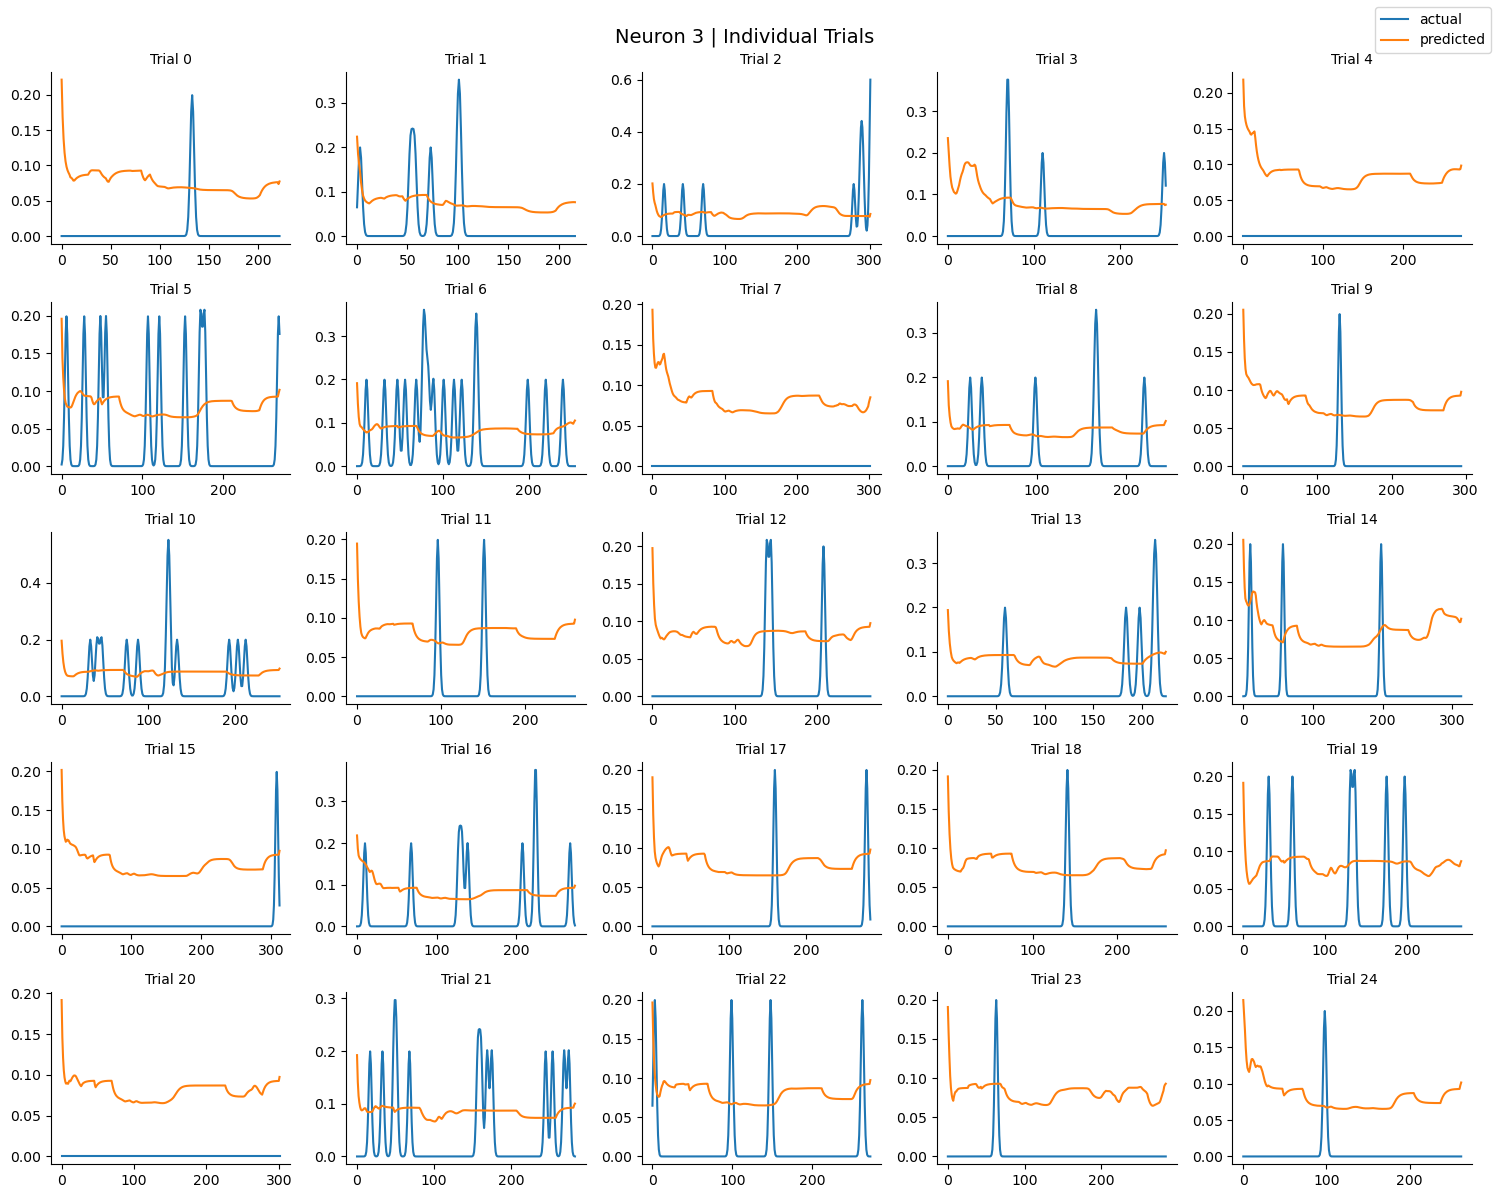

In [59]:
#plot single trials for example neuron!
import numpy as np
import matplotlib.pyplot as plt

neuron = 3  # Specify neuron index
n_trials = min(25, len(Y_test_trials))

# --- Plot individual trials (5x5) ---
fig, axes = plt.subplots(5, 5, figsize=(15, 12))
axes = axes.flatten()

for trial in range(n_trials):

    axes[trial].plot(
        Y_test_trials[trial][:, neuron],
        label="actual"
    )

    axes[trial].plot(
        yhat_test[trial][:, neuron],
        label="predicted"
    )

    axes[trial].set_title(f"Trial {trial}", fontsize=10)

   
    axes[trial].spines["top"].set_visible(False)
    axes[trial].spines["right"].set_visible(False)

for ax in axes[n_trials:]:
    ax.set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

fig.suptitle(f"Neuron {neuron} | Individual Trials", fontsize=14)
plt.tight_layout()

plt.show()



# # --- Plot mean activity across trials ---
# # Stack trials: (trials, timepoints)
# actual = np.stack([
#     Y_test_trials[trial][:, neuron]
#     for trial in range(n_trials)
# ])

# predicted = np.stack([
#     yhat_test[trial][:, neuron]
#     for trial in range(n_trials)
# ])

# # Mean across trials
# mean_actual = np.mean(actual, axis=0)
# mean_predicted = np.mean(predicted, axis=0)

# # --- Plot ---
# plt.figure(figsize=(6, 4))

# plt.plot(mean_actual, label="Mean actual", color="black")
# plt.plot(mean_predicted, label="Mean predicted", color="red")

# plt.xlabel("Time")
# plt.ylabel("Activity")
# plt.title(f"Neuron {neuron} | Mean Across {n_trials} Trials")
# plt.legend()
# plt.tight_layout()
# plt.show()


In [ ]:
from scipy.stats import pearsonr
import numpy as np

n_neurons = Y_test_trials[0].shape[1]

r_test = np.full(n_neurons, np.nan)

for n in range(n_neurons):

    actual = []
    predicted = []

    for trial in range(len(Y_test_trials)):

        actual.append(Y_test_trials[trial][:, n])
        predicted.append(yhat_test[trial][:, n])

    actual = np.concatenate(actual)
    predicted = np.concatenate(predicted)

    if np.std(actual) > 0 and np.std(predicted) > 0:
        r_test[n] = pearsonr(actual, predicted)[0]

print("Mean test r:", np.nanmean(r_test))
print("Median test r:", np.nanmedian(r_test))
print("% neurons r > 0:", np.mean(r_test[~np.isnan(r_test)] > 0) * 100)
print("% neurons r > 0.2:", np.mean(r_test[~np.isnan(r_test)] > 0.2) * 100)
print("% neurons r > 0.3:", np.mean(r_test[~np.isnan(r_test)] > 0.3) * 100)

print("\nNeuron 5 test r:", r_test[5])
print("Neuron 3 test r:", r_test[3])

# this tells use that train vs test r are similar, so model is not overfitting to training data
# train seems better than test for high r neurons

Mean test r: 0.1322762555496489
Median test r: 0.1071412700045766
% neurons r > 0: 92.46753246753246
% neurons r > 0.2: 22.857142857142858
% neurons r > 0.3: 9.61038961038961

Neuron 5 test r: 0.4349016517850468
Neuron 3 test r: 0.05430291561707125


In [ ]:
#testing if across vs within trial correlations are similar, to see if model is overfitting to trial idiosyncrasies
from scipy.stats import pearsonr
import numpy as np

n_neurons = Y_test_trials[0].shape[1]

trial_r = [[] for _ in range(n_neurons)]

for k in range(len(Y_test_trials)):

    Y = Y_test_trials[k]
    Yhat = yhat_test[k]

    for n in range(n_neurons):

        actual = Y[:, n]
        predicted = Yhat[:, n]

        if np.std(actual) > 0 and np.std(predicted) > 0:
            r = pearsonr(actual, predicted)[0]
            trial_r[n].append(r)

mean_trial_r = np.array([
    np.mean(r) if len(r) > 0 else np.nan
    for r in trial_r
])

print("Mean neuron-wise trial r:", np.nanmean(mean_trial_r))
print("Median neuron-wise trial r:", np.nanmedian(mean_trial_r))

print("\nNeuron 5 mean trial r:", mean_trial_r[5])
print("Neuron 3 mean trial r:", mean_trial_r[3])

Mean neuron-wise trial r: 0.11583374138070338
Median neuron-wise trial r: 0.09087460580601102

Neuron 5 mean trial r: 0.39032499657265096
Neuron 3 mean trial r: 0.037657514973818924


Mean valid trials/neuron: 51.28051948051948
Median valid trials/neuron: 55.0
Min: 6
Max: 62

Neuron 5 valid trials: 60
Neuron 3 valid trials: 55


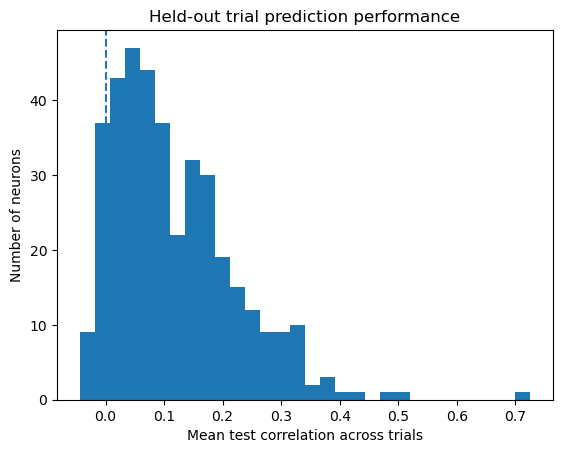

In [ ]:
#checking valid trials per neuron
valid_trials_per_neuron = np.array([
    len(r) for r in trial_r
])

print("Mean valid trials/neuron:", np.mean(valid_trials_per_neuron))
print("Median valid trials/neuron:", np.median(valid_trials_per_neuron))
print("Min:", np.min(valid_trials_per_neuron))
print("Max:", np.max(valid_trials_per_neuron))

print("\nNeuron 5 valid trials:", valid_trials_per_neuron[5])
print("Neuron 3 valid trials:", valid_trials_per_neuron[3])


import matplotlib.pyplot as plt

plt.hist(mean_trial_r[~np.isnan(mean_trial_r)], bins=30)
plt.axvline(0, linestyle="--")

plt.xlabel("Mean test correlation across trials")
plt.ylabel("Number of neurons")
plt.title("Held-out trial prediction performance")
plt.show()

PYR: mean r = 0.112, median = 0.087, n = 324
PV:  mean r = 0.148, median = 0.122, n = 43
SOM: mean r = 0.121, median = 0.085, n = 15


C:\Users\runyan1\AppData\Local\Temp\ipykernel_37624\1011169289.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['PYR', 'PV', 'SOM'], showfliers=False)


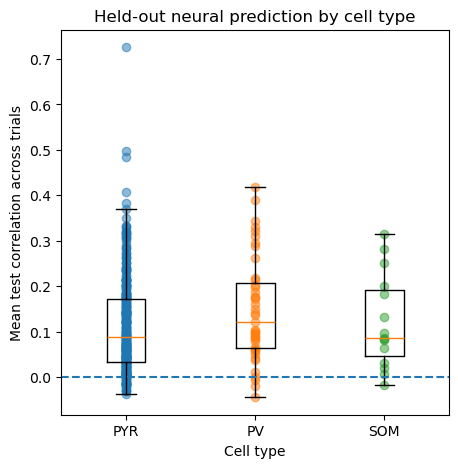

In [68]:
#compare prediction performance across cell types
pyr_r = mean_trial_r[neuron_groups['pyr']]
pv_r  = mean_trial_r[neuron_groups['pv']]
som_r = mean_trial_r[neuron_groups['som']]

# optionally require a reasonable number of valid test trials
min_trials = 10

pyr_idx = neuron_groups['pyr']
pv_idx  = neuron_groups['pv']
som_idx = neuron_groups['som']

pyr_r = mean_trial_r[pyr_idx][valid_trials_per_neuron[pyr_idx] >= min_trials]
pv_r  = mean_trial_r[pv_idx][valid_trials_per_neuron[pv_idx] >= min_trials]
som_r = mean_trial_r[som_idx][valid_trials_per_neuron[som_idx] >= min_trials]

print(f"PYR: mean r = {np.nanmean(pyr_r):.3f}, "
      f"median = {np.nanmedian(pyr_r):.3f}, n = {len(pyr_r)}")

print(f"PV:  mean r = {np.nanmean(pv_r):.3f}, "
      f"median = {np.nanmedian(pv_r):.3f}, n = {len(pv_r)}")

print(f"SOM: mean r = {np.nanmean(som_r):.3f}, "
      f"median = {np.nanmedian(som_r):.3f}, n = {len(som_r)}")

#visualize cell-type differences in prediction performance
plt.figure(figsize=(5, 5))
data = [pyr_r, pv_r, som_r]
plt.boxplot(data, labels=['PYR', 'PV', 'SOM'], showfliers=False)

# show individual neurons too
for x, vals in enumerate(data, start=1):
    plt.scatter(
        np.full(len(vals), x),
        vals,
        alpha=0.5
    )

plt.axhline(0, linestyle='--')
plt.ylabel("Mean test correlation across trials")
plt.xlabel("Cell type")
plt.title("Held-out neural prediction by cell type")
plt.show()

Activity vs prediction
Spearman rho: 0.39883219626732064
p: 5.126360603601916e-16


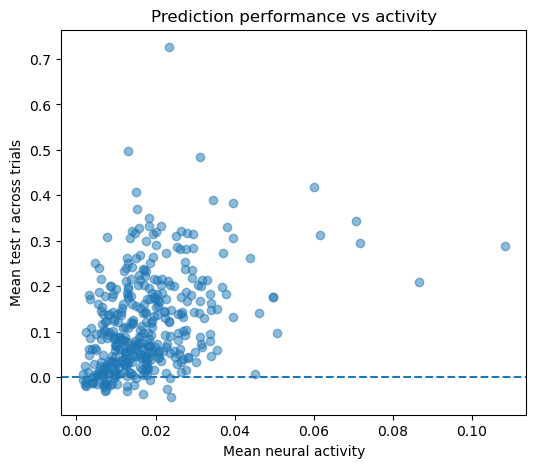

In [69]:
# Mean activity for every neuron across TEST trials
activity_sum = np.zeros(n_neurons)
sample_count = np.zeros(n_neurons)

for Y in Y_test_trials:
    activity_sum += Y.sum(axis=0)
    sample_count += Y.shape[0]

mean_activity = activity_sum / sample_count

# Only neurons included in our trial-wise analysis
valid = (
    ~np.isnan(mean_trial_r) &
    (valid_trials_per_neuron >= 10)
)

from scipy.stats import spearmanr

rho, p = spearmanr(
    mean_activity[valid],
    mean_trial_r[valid]
)

print("Activity vs prediction")
print("Spearman rho:", rho)
print("p:", p)

plt.figure(figsize=(6,5))
plt.scatter(
    mean_activity[valid],
    mean_trial_r[valid],
    alpha=0.5
)

plt.axhline(0, linestyle="--")
plt.xlabel("Mean neural activity")
plt.ylabel("Mean test r across trials")
plt.title("Prediction performance vs activity")
plt.show()

In [72]:
import numpy as np
import torch
from scipy.stats import pearsonr

# ============================================================
# Evaluate model on held-out trials
# ============================================================

model.eval()

all_Y = []
all_Yhat = []

trial_r = [[] for _ in range(Y_test_trials[0].shape[1])]

choice_preds = []
choice_actual = []

with torch.no_grad():

    for k in range(len(X_test_trials_torch)):

        # ----- Input -----
        X = X_test_trials_torch[k]

        # Y_test_trials is already numpy
        Y = Y_test_trials[k]

        # ----- Model prediction -----
        logits, hidden_states, yhat = model.forward_trial(X)

        # Your yhat appears to already be numpy in your current setup.
        # This handles either numpy OR torch safely.
        if torch.is_tensor(yhat):
            Yhat = yhat.detach().cpu().numpy()
        else:
            Yhat = np.asarray(yhat)

        # ====================================================
        # Store neural predictions
        # ====================================================

        all_Y.append(Y)
        all_Yhat.append(Yhat)

        # ====================================================
        # Trial-wise neural correlations
        # ====================================================

        for n in range(Y.shape[1]):

            actual = Y[:, n]
            predicted = Yhat[:, n]

            if np.std(actual) > 0 and np.std(predicted) > 0:
                r = pearsonr(actual, predicted)[0]

                if np.isfinite(r):
                    trial_r[n].append(r)

        # ====================================================
        # Behavioral prediction
        # ====================================================

        pred_choice = torch.argmax(logits).item()

        choice_preds.append(pred_choice)
        choice_actual.append(int(correct_test[k]))


# ============================================================
# Concatenate trials
# ============================================================

Y_all = np.concatenate(all_Y, axis=0)
Yhat_all = np.concatenate(all_Yhat, axis=0)

n_neurons = Y_all.shape[1]


# ============================================================
# 1. NEURON-WISE CORRELATION
#
# Concatenate all held-out trials, then calculate one r/neuron
# ============================================================

neuron_r = np.full(n_neurons, np.nan)

for n in range(n_neurons):

    actual = Y_all[:, n]
    predicted = Yhat_all[:, n]

    if np.std(actual) > 0 and np.std(predicted) > 0:

        r = pearsonr(actual, predicted)[0]

        if np.isfinite(r):
            neuron_r[n] = r


print("\n========== NEURAL PREDICTION ==========")

print(
    f"Mean neuron-wise r:   {np.nanmean(neuron_r):.3f}"
)

print(
    f"Median neuron-wise r: {np.nanmedian(neuron_r):.3f}"
)


# ============================================================
# 2. TRIAL-WISE CORRELATION
#
# Calculate r separately on each trial, then average within
# each neuron.
# ============================================================

mean_trial_r = np.array([
    np.mean(rs) if len(rs) > 0 else np.nan
    for rs in trial_r
])

print("\n========== TRIAL-WISE PREDICTION ==========")

print(
    f"Mean trial-wise r:    {np.nanmean(mean_trial_r):.3f}"
)

print(
    f"Median trial-wise r:  {np.nanmedian(mean_trial_r):.3f}"
)


# ============================================================
# 3. CALIBRATION
#
# Is the model predicting approximately the correct amount
# of activity overall?
# ============================================================

actual_mean = np.mean(Y_all)
predicted_mean = np.mean(Yhat_all)

mean_bias = predicted_mean - actual_mean

print("\n========== CALIBRATION ==========")

print(f"Actual mean activity:    {actual_mean:.5f}")
print(f"Predicted mean activity: {predicted_mean:.5f}")
print(f"Prediction bias:         {mean_bias:+.5f}")
print(
    f"Predicted / actual:      "
    f"{predicted_mean / actual_mean:.2f}x"
)


# ============================================================
# 4. BEHAVIORAL PERFORMANCE
# ============================================================

choice_preds = np.asarray(choice_preds)
choice_actual = np.asarray(choice_actual)

choice_accuracy = np.mean(choice_preds == choice_actual)

# Majority-class baseline
p_correct = np.mean(choice_actual)
chance_accuracy = max(p_correct, 1 - p_correct)

print("\n========== BEHAVIOR ==========")

print(f"Choice accuracy:         {choice_accuracy:.3f}")
print(f"Majority-class baseline: {chance_accuracy:.3f}")
print(f"N trials:                {len(choice_actual)}")


========== NEURAL PREDICTION ==========
Mean neuron-wise r:   0.132
Median neuron-wise r: 0.107

========== TRIAL-WISE PREDICTION ==========
Mean trial-wise r:    0.116
Median trial-wise r:  0.091

========== CALIBRATION ==========
Actual mean activity:    0.01757
Predicted mean activity: 0.05378
Prediction bias:         +0.03622
Predicted / actual:      3.06x

========== BEHAVIOR ==========
Choice accuracy:         0.790
Majority-class baseline: 0.790
N trials:                62


In [74]:
from sklearn.metrics import balanced_accuracy_score, confusion_matrix

balanced_acc = balanced_accuracy_score(
    choice_actual,
    choice_preds
)

print("Accuracy:", choice_accuracy)
print("Balanced accuracy:", balanced_acc)
print("\nConfusion matrix:")
print(confusion_matrix(choice_actual, choice_preds))

Accuracy: 0.7903225806451613
Balanced accuracy: 0.5

Confusion matrix:
[[ 0 13]
 [ 0 49]]


In [71]:
# Fraction of timepoints containing an event for each neuron
import scipy.stats as stats
all_test_Y = np.concatenate(Y_test_trials, axis=0)

event_rate = np.mean(all_test_Y > 0, axis=0)

valid = (
    ~np.isnan(mean_trial_r) &
    (valid_trials_per_neuron >= 10)
)

rho, p = stats.spearmanr(
    event_rate[valid],
    mean_trial_r[valid]
)

print(f"Event rate vs predictability: rho={rho:.3f}, p={p:.4g}")

Event rate vs predictability: rho=0.247, p=9.939e-07


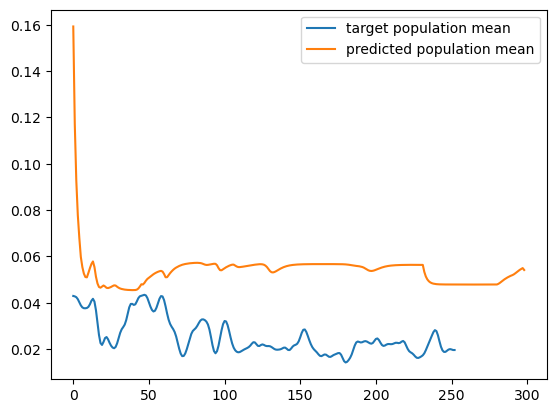

In [60]:
mean_target_t = Y_trial.mean(dim=1).detach().cpu().numpy()
mean_pred_t = yhat.mean(dim=1).detach().cpu().numpy()

plt.figure()
plt.plot(mean_target_t, label="target population mean")
plt.plot(mean_pred_t, label="predicted population mean")
plt.legend()
plt.show()

In [20]:
print(yhat.mean().item(), Y_trial.mean().item())
print(yhat.min().item(), yhat.max().item())

0.026739180088043213 0.025269974023103714
1.6209527302635252e-06 0.40310028195381165


below are previous loading functions

In [ ]:
import argparse
import encoding_GLM as glm #1 import GLM package
import glm_wrapper_functions_cluster as glm_wrapper #2 import wrapper functions that run glm
import importlib
importlib.reload(glm_wrapper)
import os
import pickle
from scipy import stats
import numpy as np


def run_glm_model_poss_updated(cellid,mouse,date,model_type,model_name):

    

    data_directory = os.path.join('/ix/crunyan/cdb66/Data',mouse,date,model_name) #SLURM ALREADY CD's to the directory
    save_directory = os.path.join('/ix/crunyan/cdb66/Data',mouse,date,model_name,'results_updated')


    print(f"Running model for neuron {cellid}")
    num_folds = 10
    model_data_all = {}
    for fold_number in list(range(0,num_folds)): #can change this to fit however many folds you need 

        train_directory = data_directory + "/prepost trial cv 73 #{}".format(fold_number+1)
        test_directory = data_directory + "/prepost trial cv 73 #{}/test".format(fold_number+1)

        #print(f"Running model for neuron {cellid}")
        #[X_train, Y_train, X_test, Y_test, count_of_values, IDS_for_count_of_values] = glm_wrapper.glm_wrapper_functions_cluster.get_coupling_data_from_each_CV_fold_rawdeconv(train_directory, test_directory, fold_number+1, cel, 1)
        #[X_train, Y_train, X_test, Y_test, count_of_values, IDS_for_count_of_values] = glm_wrapper.glm_wrapper_functions_cluster.get_data_from_each_CV_fold(train_directory, test_directory, fold_number+1)
        if model_type == "0": 
            [X_train, Y_train, X_test, Y_test, count_of_values, IDS_for_count_of_values] = glm_wrapper.glm_wrapper_functions_cluster.get_data_from_each_CV_fold_rawdeconv(train_directory, test_directory, fold_number+1, cel)
            #z score predictors
            X_test = safe_zscore(X_test) #stats.zscore(X_test, axis=0, nan_policy='omit') # 
            X_train = safe_zscore(X_train) #stats.zscore(X_train, axis=0, nan_policy='omit') 
        elif model_type == "1":
            print('model_type 1')
            [X_train, Y_train, X_test, Y_test, count_of_values, IDS_for_count_of_values] = glm_wrapper.glm_wrapper_functions_cluster.get_coupling_data_from_each_CV_fold_rawdeconv(train_directory, test_directory, fold_number+1, cel, 1)
            #z score predictors
            X_test = safe_zscore(X_test) #stats.zscore(X_test, axis=0, nan_policy='omit')  
            X_train = safe_zscore(X_train) # stats.zscore(X_train, axis=0, nan_policy='omit') 
        elif model_type == "2":
            print('model_type 2')
            elimination_type = 0 #get rid of first 3 coupling predictors (PYR)
            [X_train, Y_train, X_test, Y_test, count_of_values, IDS_for_count_of_values] = glm_wrapper.glm_wrapper_functions_cluster.get_coupling_data_from_each_CV_fold_rawdeconv(train_directory, test_directory, fold_number+1, cel, 1, elimination_option = elimination_type)
            #z score predictors
            X_test = safe_zscore(X_test) #stats.zscore(X_test, axis=0, nan_policy='omit') 
            X_train = safe_zscore(X_train) # stats.zscore(X_train, axis=0, nan_policy='omit') 
        elif model_type == "3":
            print('model_type 3')
            elimination_type = 1 #get rid of second 3 coupling predictors (SOM)
            [X_train, Y_train, X_test, Y_test, count_of_values, IDS_for_count_of_values] = glm_wrapper.glm_wrapper_functions_cluster.get_coupling_data_from_each_CV_fold_rawdeconv(train_directory, test_directory, fold_number+1, cel, 1,  elimination_option = elimination_type)
            #z score predictors
            X_test = safe_zscore(X_test) #stats.zscore(X_test, axis=0, nan_policy='omit') 
            X_train = safe_zscore(X_train) # stats.zscore(X_train, axis=0, nan_policy='omit') 
        elif model_type == "4":
            print('model_type 4')
            elimination_type = 2 #get rid of last 3 coupling predictors (PV)
            [X_train, Y_train, X_test, Y_test, count_of_values, IDS_for_count_of_values] = glm_wrapper.glm_wrapper_functions_cluster.get_coupling_data_from_each_CV_fold_rawdeconv(train_directory, test_directory, fold_number+1, cel, 1,  elimination_option = elimination_type)
            #z score predictors
            X_test = safe_zscore(X_test) #stats.zscore(X_test, axis=0, nan_policy='omit')  
            X_train = safe_zscore(X_train) # stats.zscore(X_train, axis=0, nan_policy='omit') 

        elif model_type == "5":
            print('model_type 5')
            [X_train, Y_train, X_test, Y_test, count_of_values, IDS_for_count_of_values] = glm_wrapper.glm_wrapper_functions_cluster.get_coupling_data_from_each_CV_fold_rawdeconv_all_neurons(train_directory, test_directory, fold_number+1, cel, 1)
            #z score predictors
            X_test = safe_zscore(X_test) #stats.zscore(X_test, axis=0, nan_policy='omit')  
            X_train = safe_zscore(X_train) # stats.zscore(X_train, axis=0, nan_policy='omit') 

        #train model on GPU!
        model_trained = glm_wrapper.glm_wrapper_functions_cluster.train_model_on_cv_fold_GPU(X_train, Y_train, count_of_values, activation, loss_type, regularization, l1_ratio) 
        model_trained.select_model(X_test, Y_test, min_lambda = 0.0, make_fig = False)
        frac_dev_expl, dev_model, dev_null, dev_expl = model_trained.evaluate(X_test, Y_test, make_fig = False)
        B_weights = model_trained.selected_w
        intercept_weight = model_trained.selected_w0
        y_pred = model_trained.predict(X_test)
        selec_lambda = model_trained.selected_lambda


        # Extract additional hyperparameter information
        # loss_trace = model_trained.loss_trace
        # lambda_trace = model_trained.lambda_trace


        model_data = {
        'frac_dev_expl': frac_dev_expl,
        'dev_model': dev_model,
        'dev_null': dev_null, 
        'dev_expl': dev_expl, 
        'B_weights': B_weights,
        'intercept_weight': intercept_weight,
        'y_pred': y_pred,
        'selec_lambda': selec_lambda,
        # 'loss_trace': loss_trace,
        # 'lambda_trace': lambda_trace
        }

        ##below saves each cell in each fold- I will change to save just once when the entire fold is done running?
        # os.chdir(train_directory)

        # with open('model_data_cluster_' + cellid + '.pkl', 'wb') as file:
        #     pickle.dump(model_data, file) #add cell number to know that it was fit
        model_data_all[fold_number] = model_data

    os.makedirs(save_directory, exist_ok=True)
    os.chdir(save_directory)
    with open('poss_model_'+model_type+ '_data_cluster_' + cellid + '.pkl', 'wb') as file:
        pickle.dump(model_data_all, file) #add cell number to know that it was fit

    return model_data


In [ ]:
import argparse
import encoding_GLM as glm #1 import GLM package
import glm_wrapper_functions_cluster as glm_wrapper #2 import wrapper functions that run glm
import importlib
importlib.reload(glm_wrapper)
import os
import pickle
from scipy import stats
import numpy as np


def run_glm_model_poss_updated(cellid,mouse,date,model_type,model_name):

    #1) specify model parameters 
    activation, loss_type, regularization, l1_ratio = 'exp', 'poisson', 'elastic_net', .95 #poisson or binomial
    #activation, loss_type, regularization, l1_ratio = 'sigmoid', 'binominal', 'elastic_net', .95 

    #2) make cel number into double and allow access to code
    cel = int(cellid)

    #3) get train and test directories

    # current directories
    # data_directory = "/ihome/crunyan/cdb66/Data" #SLURM ALREADY CD's to the directory
    # save_directory = "/ihome/crunyan/cdb66/Data"

    data_directory = os.path.join('/ix/crunyan/cdb66/Data',mouse,date,model_name) #SLURM ALREADY CD's to the directory
    save_directory = os.path.join('/ix/crunyan/cdb66/Data',mouse,date,model_name,'results_updated')

    # 4) check to see if we already run this particular neuron
    file_name = 'poss_model_' + model_type + '_data_cluster_' + cellid + '.pkl'
    file_path = os.path.join(save_directory, file_name)
    # if os.path.exists(file_path):
    #     print(f"File {file_path} already exists. Skipping model run.")
    #     return

    print(f"Running model for neuron {cellid}")
    num_folds = 10
    model_data_all = {}
    for fold_number in list(range(0,num_folds)): #can change this to fit however many folds you need 

        train_directory = data_directory + "/prepost trial cv 73 #{}".format(fold_number+1)
        test_directory = data_directory + "/prepost trial cv 73 #{}/test".format(fold_number+1)

        #print(f"Running model for neuron {cellid}")
        #[X_train, Y_train, X_test, Y_test, count_of_values, IDS_for_count_of_values] = glm_wrapper.glm_wrapper_functions_cluster.get_coupling_data_from_each_CV_fold_rawdeconv(train_directory, test_directory, fold_number+1, cel, 1)
        #[X_train, Y_train, X_test, Y_test, count_of_values, IDS_for_count_of_values] = glm_wrapper.glm_wrapper_functions_cluster.get_data_from_each_CV_fold(train_directory, test_directory, fold_number+1)
        if model_type == "0": 
            [X_train, Y_train, X_test, Y_test, count_of_values, IDS_for_count_of_values] = glm_wrapper.glm_wrapper_functions_cluster.get_data_from_each_CV_fold_rawdeconv(train_directory, test_directory, fold_number+1, cel)
            #z score predictors
            X_test = safe_zscore(X_test) #stats.zscore(X_test, axis=0, nan_policy='omit') # 
            X_train = safe_zscore(X_train) #stats.zscore(X_train, axis=0, nan_policy='omit') 
        elif model_type == "1":
            print('model_type 1')
            [X_train, Y_train, X_test, Y_test, count_of_values, IDS_for_count_of_values] = glm_wrapper.glm_wrapper_functions_cluster.get_coupling_data_from_each_CV_fold_rawdeconv(train_directory, test_directory, fold_number+1, cel, 1)
            #z score predictors
            X_test = safe_zscore(X_test) #stats.zscore(X_test, axis=0, nan_policy='omit')  
            X_train = safe_zscore(X_train) # stats.zscore(X_train, axis=0, nan_policy='omit') 
        elif model_type == "2":
            print('model_type 2')
            elimination_type = 0 #get rid of first 3 coupling predictors (PYR)
            [X_train, Y_train, X_test, Y_test, count_of_values, IDS_for_count_of_values] = glm_wrapper.glm_wrapper_functions_cluster.get_coupling_data_from_each_CV_fold_rawdeconv(train_directory, test_directory, fold_number+1, cel, 1, elimination_option = elimination_type)
            #z score predictors
            X_test = safe_zscore(X_test) #stats.zscore(X_test, axis=0, nan_policy='omit') 
            X_train = safe_zscore(X_train) # stats.zscore(X_train, axis=0, nan_policy='omit') 
        elif model_type == "3":
            print('model_type 3')
            elimination_type = 1 #get rid of second 3 coupling predictors (SOM)
            [X_train, Y_train, X_test, Y_test, count_of_values, IDS_for_count_of_values] = glm_wrapper.glm_wrapper_functions_cluster.get_coupling_data_from_each_CV_fold_rawdeconv(train_directory, test_directory, fold_number+1, cel, 1,  elimination_option = elimination_type)
            #z score predictors
            X_test = safe_zscore(X_test) #stats.zscore(X_test, axis=0, nan_policy='omit') 
            X_train = safe_zscore(X_train) # stats.zscore(X_train, axis=0, nan_policy='omit') 
        elif model_type == "4":
            print('model_type 4')
            elimination_type = 2 #get rid of last 3 coupling predictors (PV)
            [X_train, Y_train, X_test, Y_test, count_of_values, IDS_for_count_of_values] = glm_wrapper.glm_wrapper_functions_cluster.get_coupling_data_from_each_CV_fold_rawdeconv(train_directory, test_directory, fold_number+1, cel, 1,  elimination_option = elimination_type)
            #z score predictors
            X_test = safe_zscore(X_test) #stats.zscore(X_test, axis=0, nan_policy='omit')  
            X_train = safe_zscore(X_train) # stats.zscore(X_train, axis=0, nan_policy='omit') 

        elif model_type == "5":
            print('model_type 5')
            [X_train, Y_train, X_test, Y_test, count_of_values, IDS_for_count_of_values] = glm_wrapper.glm_wrapper_functions_cluster.get_coupling_data_from_each_CV_fold_rawdeconv_all_neurons(train_directory, test_directory, fold_number+1, cel, 1)
            #z score predictors
            X_test = safe_zscore(X_test) #stats.zscore(X_test, axis=0, nan_policy='omit')  
            X_train = safe_zscore(X_train) # stats.zscore(X_train, axis=0, nan_policy='omit') 

        #train model on GPU!
        model_trained = glm_wrapper.glm_wrapper_functions_cluster.train_model_on_cv_fold_GPU(X_train, Y_train, count_of_values, activation, loss_type, regularization, l1_ratio) 
        model_trained.select_model(X_test, Y_test, min_lambda = 0.0, make_fig = False)
        frac_dev_expl, dev_model, dev_null, dev_expl = model_trained.evaluate(X_test, Y_test, make_fig = False)
        B_weights = model_trained.selected_w
        intercept_weight = model_trained.selected_w0
        y_pred = model_trained.predict(X_test)
        selec_lambda = model_trained.selected_lambda


        # Extract additional hyperparameter information
        # loss_trace = model_trained.loss_trace
        # lambda_trace = model_trained.lambda_trace


        model_data = {
        'frac_dev_expl': frac_dev_expl,
        'dev_model': dev_model,
        'dev_null': dev_null, 
        'dev_expl': dev_expl, 
        'B_weights': B_weights,
        'intercept_weight': intercept_weight,
        'y_pred': y_pred,
        'selec_lambda': selec_lambda,
        # 'loss_trace': loss_trace,
        # 'lambda_trace': lambda_trace
        }

        ##below saves each cell in each fold- I will change to save just once when the entire fold is done running?
        # os.chdir(train_directory)

        # with open('model_data_cluster_' + cellid + '.pkl', 'wb') as file:
        #     pickle.dump(model_data, file) #add cell number to know that it was fit
        model_data_all[fold_number] = model_data

    os.makedirs(save_directory, exist_ok=True)
    os.chdir(save_directory)
    with open('poss_model_'+model_type+ '_data_cluster_' + cellid + '.pkl', 'wb') as file:
        pickle.dump(model_data_all, file) #add cell number to know that it was fit

    return model_data
